In [154]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [155]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [156]:
print(data['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [157]:
X = pd.DataFrame(data['data'],columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])
y = data['target']

In [158]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=30)

In [159]:
X_train.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
110,0.041708,0.050680,-0.032073,-0.022885,-0.049727,-0.040144,0.030232,-0.039493,-0.126097,0.015491
415,-0.005515,-0.044642,0.008883,-0.050427,0.025950,0.047224,-0.043401,0.071210,0.014821,0.003064
426,0.030811,0.050680,-0.034229,0.043666,0.057597,0.068831,-0.032356,0.057557,0.035459,0.085907
332,0.030811,-0.044642,0.104809,0.076958,-0.011201,-0.011335,-0.058127,0.034309,0.057108,0.036201
13,0.005383,0.050680,-0.001895,0.008101,-0.004321,-0.015719,-0.002903,-0.002592,0.038394,-0.013504


<Axes: >

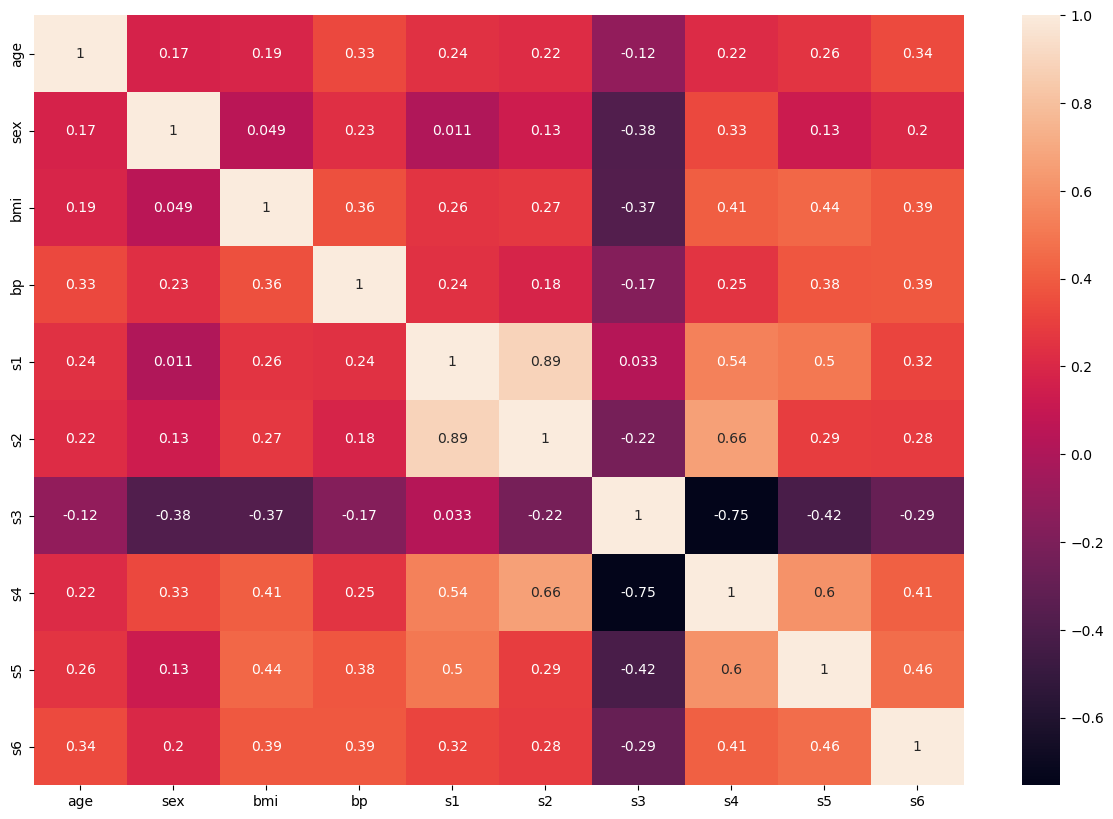

In [160]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [161]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


HyperParameter Tuning


In [162]:
param = {
    'criterion': ['squared_error','friedman_mse','absolute_error'],
    'splitter': ['best','random'],
    'max_depth': [1,2,3,4,5,10,15,20,25],
    'max_features': ['auto','sqrt','log2']
}

In [163]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(regressor,param_grid=param,scoring='neg_mean_squared_error')
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [164]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [165]:
y_pred = grid.predict(X_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.39320582969302775
3730.7648312371275
49.62881654243199


In [169]:
model = DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='sqrt',splitter='best')
model.fit(X_train,y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.9, 'x[2] <= -0.007\nfriedman_mse = 5867.617\nsamples = 353\nvalue = 153.337'),
 Text(0.25, 0.7, 'x[8] <= -0.004\nfriedman_mse = 2900.841\nsamples = 178\nvalue = 112.253'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[6] <= 0.089\nfriedman_mse = 1963.174\nsamples = 128\nvalue = 97.289'),
 Text(0.0625, 0.3, 'x[3] <= 0.101\nfriedman_mse = 2028.362\nsamples = 116\nvalue = 100.293'),
 Text(0.03125, 0.1, 'friedman_mse = 1928.57\nsamples = 115\nvalue = 99.287'),
 Text(0.09375, 0.1, 'friedman_mse = 0.0\nsamples = 1\nvalue = 216.0'),
 Text(0.1875, 0.3, 'x[0] <= -0.004\nfriedman_mse = 402.521\nsamples = 12\nvalue = 68.25'),
 Text(0.15625, 0.1, 'friedman_mse = 78.889\nsamples = 6\nvalue = 55.667'),
 Text(0.21875, 0.1, 'friedman_mse = 409.472\nsamples = 6\nvalue = 80.833'),
 Text(0.375, 0.5, 'x[3] <= 0.039\nfriedman_mse = 3260.606\nsamples = 50\nvalue = 150.56'),
 Text(0.3125, 0.3, 'x[9] <= -0.076\nfriedman_mse = 2650.519\nsamples = 38\nvalue = 137.816'),
 Text(0.28125, 0.1, 'fri

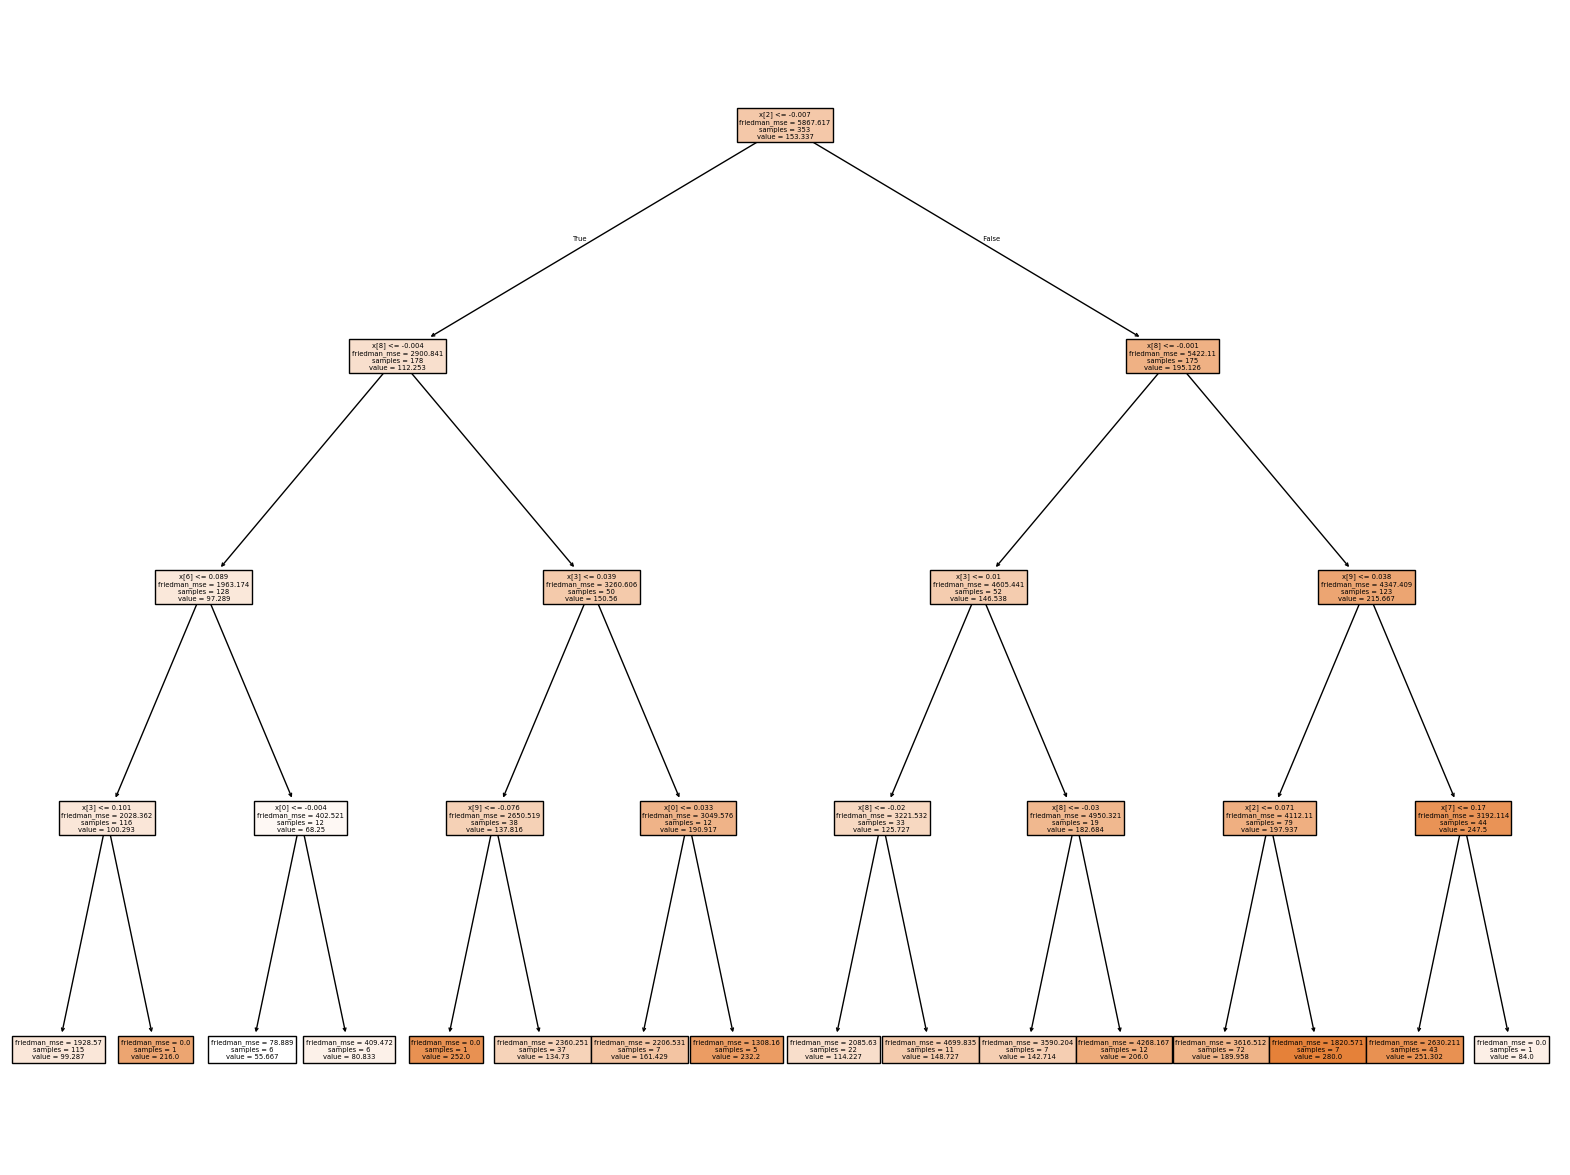

In [173]:
from sklearn import tree
plt.figure(figsize=(20,15))
tree.plot_tree(model,filled=True)
